In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated

from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage
from dotenv import load_dotenv

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

load_dotenv()

True

In [2]:
summary_llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
llm = ChatGroq(model="openai/gpt-oss-120b")

In [ ]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

def get_response(state: ChatState):

    response=llm.invoke(state['messages'])
    return {'messages': [response]}
from langchain_core.messages
def delete_chat(state: ChatState):

    messages = state['messages']
    if len(messages) > 10:
        to_remove = messages[:6]
        return {'messages':[RemoveMessage(id=msg.id) for msg in to_remove]}
    return {}

In [4]:
builder = StateGraph(ChatState)

builder.add_node('response',get_response)
builder.add_node('cleanup',delete_chat)

builder.add_edge(START, 'response')
builder.add_edge('response','cleanup')
builder.add_edge('cleanup',END)

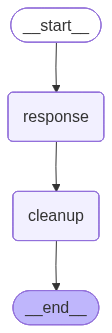

In [5]:
cp=InMemorySaver()

chatbot = builder.compile(checkpointer=cp)
chatbot

In [6]:
config={'configurable':{'thread_id':"Chat-1"}}

# Run multiple turns
chatbot.invoke({"messages": [{"role": "user", "content": "Hi, I'm Prashant"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph within 200 words"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers,within 200 words"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is Langchain, within 200 words"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics,within 200 words"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is Gen AI,within 200 words"}]}, config)
chatbot.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain, within 200 words', additional_kwargs={}, response_metadata={}, id='8a370ba5-4491-4ee8-8e8d-db6c29059a84'),
  AIMessage(content='**LangChain – a 200‑word snapshot**\n\nLangChain is an open‑source Python (and JavaScript/TypeScript) framework that simplifies building applications powered by large language models (LLMs). Rather than writing raw prompt strings and API calls, developers compose **modular components** that handle prompt templating, memory, tool integration, and execution flow.\n\n**Core building blocks**\n\n| Component | Role |\n|-----------|------|\n| **PromptTemplate** | Parameterized prompt strings with variable substitution. |\n| **LLM / ChatModel** | Wrapper around OpenAI, Anthropic, Azure, HuggingFace, etc., providing a unified `.invoke()` / `.stream()` interface. |\n| **Chains** | Linear sequences of components (prompt → LLM → parser) that can be reused and nested. |\n| **Agents** | Decision‑making loops that choos

In [ ]:
snap = chatbot.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
